NOTE: Day 48 mein ek preview dekha tha Matplotlib se — aaj Seaborn se properly seekhenge, aur group-wise comparison pe focus karenge (jaise "Churned vs Not-Churned ka Monetary distribution"), jo plain Matplotlib se mushkil hota hai.

1. Setup:

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')
sns.set_style('whitegrid')

2. Basic box plot — single column (Day 48 ka revision, Seaborn se):

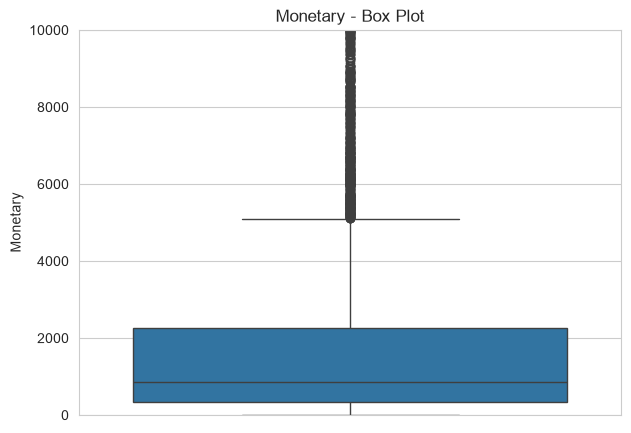

In [2]:
plt.figure(figsize=(7, 5))
sns.boxplot(y=df['Monetary'])
plt.title('Monetary - Box Plot')
plt.ylim(0, 10000)   # outliers ki wajah se scale bahut bada ho jaata hai, zoom in karo
plt.show()

Yaad karo box plot ke parts: Box = Q1 to Q3 (IQR), line beech mein = Median, whiskers = 1.5×IQR tak, dots whiskers ke bahar = outliers (Day 48 ka formula yahan visually dikhta hai).

3. Group-wise box plot — Churned vs Not-Churned (bahut powerful comparison):

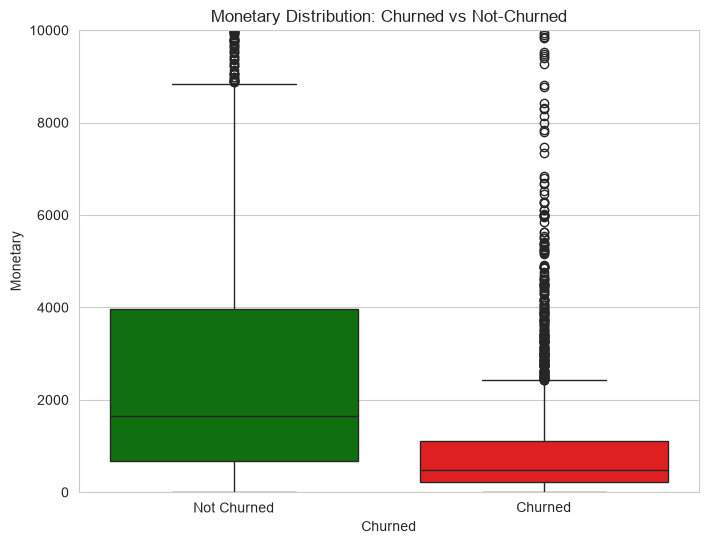

In [4]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churned', y='Monetary', hue='Churned', palette={0: 'green', 1: 'red'},legend=False)
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.ylim(0, 10000)
plt.title('Monetary Distribution: Churned vs Not-Churned')
plt.show()

note: Yeh exactly wahi comparison hai jo Day 45 mein t-test se numerically kiya tha — ab visually dekho ki medians aur spread kaise alag hain dono groups mein.

4. Multiple columns ek saath (RFM teeno, subplot mein):

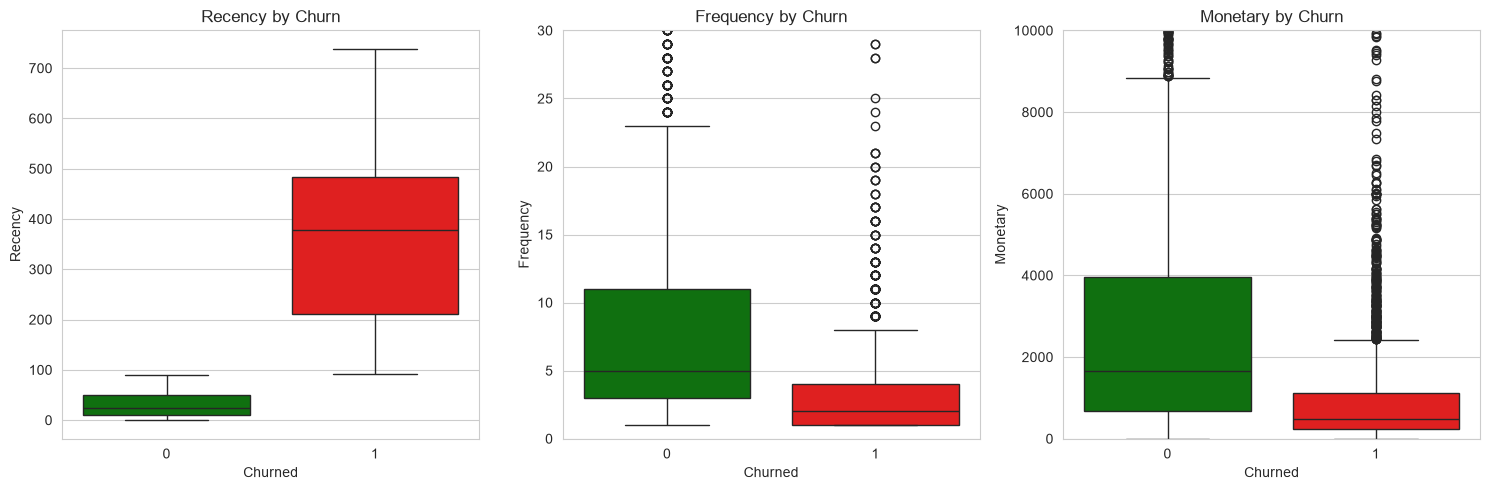

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x='Churned', y='Recency', hue='Churned', ax=axes[0], palette={0: 'green', 1: 'red'}, legend=False)
axes[0].set_title('Recency by Churn')

sns.boxplot(data=df, x='Churned', y='Frequency', hue='Churned', ax=axes[1], palette={0: 'green', 1: 'red'}, legend=False)
axes[1].set_title('Frequency by Churn')
axes[1].set_ylim(0, 30)

sns.boxplot(data=df, x='Churned', y='Monetary', hue='Churned', ax=axes[2], palette={0: 'green', 1: 'red'}, legend=False)
axes[2].set_title('Monetary by Churn')
axes[2].set_ylim(0, 10000)

plt.tight_layout()
plt.show()

5. Customer_Segment (VIP vs Regular, Day 49 wala) ke hisaab se box plot:

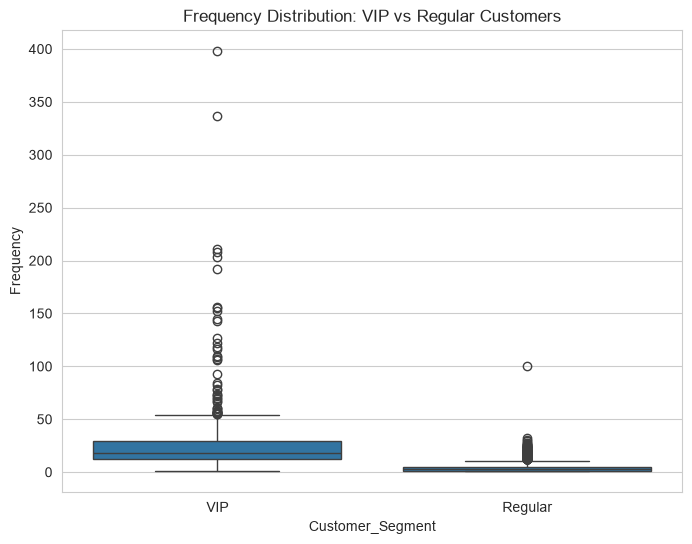

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Customer_Segment', y='Frequency')
plt.title('Frequency Distribution: VIP vs Regular Customers')
plt.show()

6. Country-wise box plot (top 5 countries, multi-category comparison):

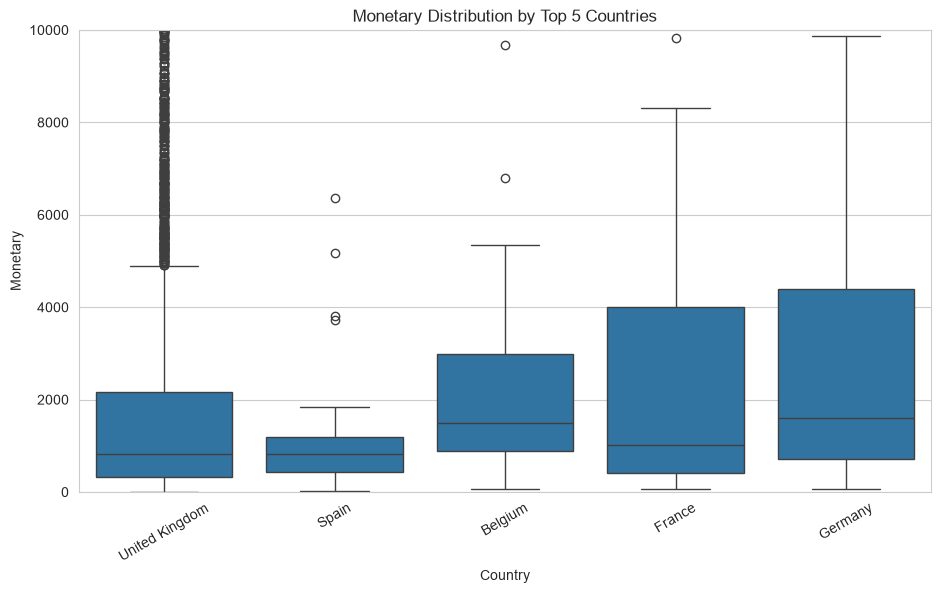

In [8]:
tx = pd.read_csv(
    '../data/processed/step4_datatypes_fixed.csv',
    dtype={'Invoice': str, 'StockCode': str},
    usecols=['Customer ID', 'Country']
)
cust_country = tx.groupby('Customer ID')['Country'].agg(lambda s: s.mode()[0]).reset_index()
df_country = df.merge(cust_country, on='Customer ID', how='left')

top5_countries = df_country['Country'].value_counts().head(5).index
subset = df_country[df_country['Country'].isin(top5_countries)]

plt.figure(figsize=(11, 6))
sns.boxplot(data=subset, x='Country', y='Monetary')
plt.ylim(0, 10000)
plt.title('Monetary Distribution by Top 5 Countries')
plt.xticks(rotation=30)
plt.show()

7. Violin plot — box plot ka "upgrade" version (distribution shape bhi dikhata hai, Day 42 ka histogram concept combine karke):

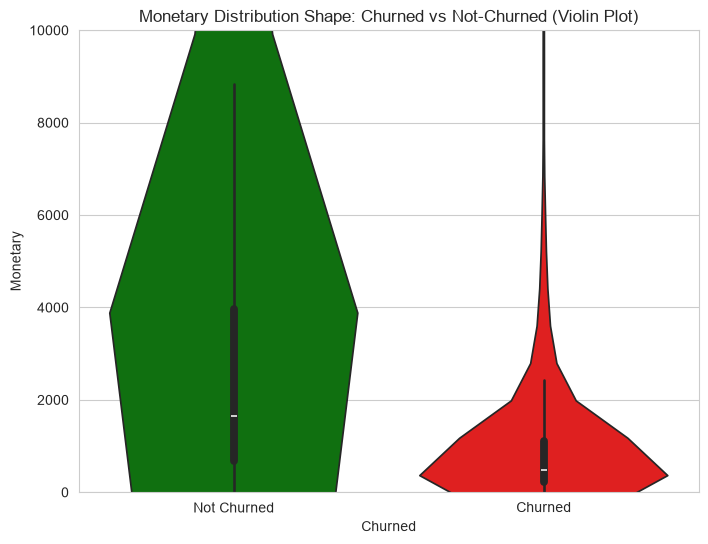

In [10]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Churned', y='Monetary', hue='Churned', palette={0: 'green', 1: 'red'}, legend=False)
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.ylim(0, 10000)
plt.title('Monetary Distribution Shape: Churned vs Not-Churned (Violin Plot)')
plt.show()

note: Violin plot box plot ke saare stats (median, IQR) ke saath-saath poora distribution shape bhi dikhata hai (jaise histogram ko side se dekhna) — jaha violin "mota" hai, wahan values zyada concentrated hain.

8. Log-transformed version (skewed data ke liye zyada readable box plot):

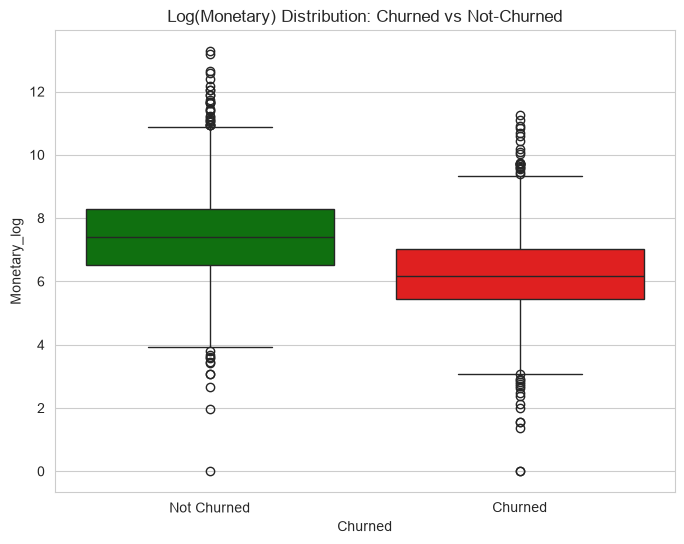

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churned', y='Monetary_log', hue='Churned', palette={0: 'green', 1: 'red'}, legend=False)
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.title('Log(Monetary) Distribution: Churned vs Not-Churned')
plt.show()

practice questions:

1. Recency ka violin plot banao Churned vs Not-Churned ke liye — shape mein kya fark dikhta hai dono groups ke beech?

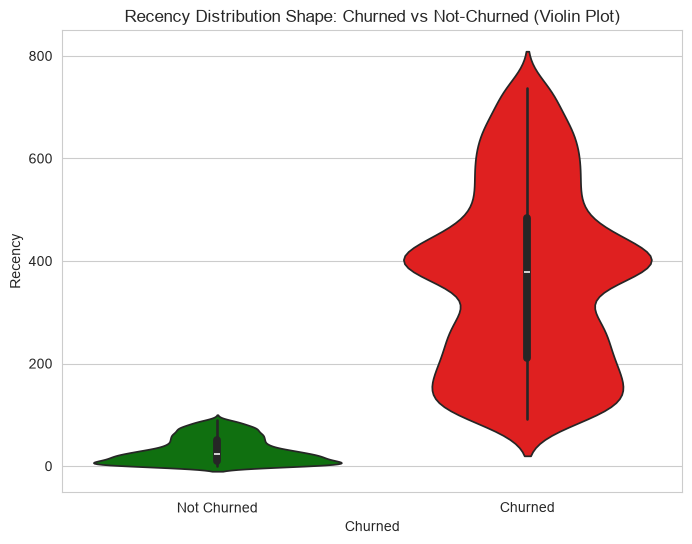

In [13]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Churned', y='Recency', hue='Churned', palette={0: 'green', 1: 'red'}, legend=False)
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.title('Recency Distribution Shape: Churned vs Not-Churned (Violin Plot)')
plt.show()

- (Observation):

    - Not Churned (Green): Iska violin zyada tar niche ki taraf (low Recency values) mota/concentrated hota hai. Iska matlab hai ki in customers ne recently hi purchase kiya hai (unki gap kam hai).

    - Churned (Red): Iska violin upar ki taraf (high Recency values) stretch ya spread hota hai. Iska matlab yeh hai ki in customers ko kafi din ho gaye hain kharidari kiye hue (long gap/inactivity), jo ki churn hone ka ek bada sign hota hai.

2. Apne notebook mein 2-3 lines likho: box plot se dekh kar, Churned customers ka Monetary median Not-Churned se zyada hai ya kam, aur yeh Day 45 ke t-test result se match karta hai kya?

- Observation: Box plot ko dekhne se pata chalta hai ki Not Churned customers ka Monetary median (aur overall spread) Churned customers ke mukable kafi zyada hai. Churned customers ka median kaafi niche (kam spending) par hai.

- Conclusion & Match: Haan, yeh result Day 45 ke t-test (hypothesis testing) se poori tarah match karta hai, jahan humne statistically prove kiya tha ki active (Not Churned) customers zyada spend karte hain aur dono groups ke means me statistically significant difference hota hai.